In [1]:
# Análisis de Anime + Clasificación con XGBoost

## Descripción del Proyecto
# Este proyecto analiza un dataset público de anime para explorar qué características están asociadas con mejores calificaciones (score). Después del análisis exploratorio de datos (EDA), se entrena un modelo de clasificación XGBoost para predecir si un anime pertenece a la categoría de alta puntuación.

## Pregunta Principal
# ¿Qué características están asociadas con mayores puntuaciones en anime, y qué tan bien puede XGBoost predecir si un anime tendrá alta calificación?

## Dataset
# Fuente: anime-standalone.csv desde un repositorio público en GitHub.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
!pip install xgboost


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [5]:
from xgboost import XGBClassifier

In [6]:
import warnings
warnings.filterwarnings("ignore")

In [7]:
df = pd.read_csv("anime-standalone.csv")
df.head()

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios
0,1,Cowboy Bebop,カウボーイビバップ,Cowboy Bebop,https://myanimelist.net/images/anime/4/19644.jpg,8.75,49.0,2051529,1059425,26,1998-04-03,1999-04-24,tv,finished_airing,r,1440,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise
1,5,Cowboy Bebop: Tengoku no Tobira,カウボーイビバップ 天国の扉,Cowboy Bebop: The Movie,https://myanimelist.net/images/anime/1439/9348...,8.38,240.0,411130,231859,1,2001-09-01,2001-09-01,movie,finished_airing,r,6911,"Action, Adult Cast, Sci-Fi, Space",Bones
2,6,Trigun,トライガン,Trigun,https://myanimelist.net/images/anime/1130/1200...,8.22,419.0,832704,400891,26,1998-04-01,1998-09-30,tv,finished_airing,pg_13,1480,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse
3,7,Witch Hunter Robin,Witch Hunter ROBIN (ウイッチハンターロビン),Witch Hunter Robin,https://myanimelist.net/images/anime/10/19969.jpg,7.25,3527.0,129287,46530,26,2002-07-03,2002-12-25,tv,finished_airing,pg_13,1500,"Action, Detective, Drama, Mystery, Supernatural",Sunrise
4,8,Bouken Ou Beet,冒険王ビィト,Beet the Vandel Buster,https://myanimelist.net/images/anime/7/21569.webp,7.01,4893.0,16881,7226,52,2004-09-30,2005-09-29,tv,finished_airing,pg,1380,"Action, Adventure, Fantasy, Shounen",Toei Animation


In [8]:
df["score"] = df["mean"]

In [9]:
df.shape

(24923, 19)

In [10]:
df.columns.tolist()

['id',
 'title',
 'titleJa',
 'titleEn',
 'image',
 'mean',
 'rank',
 'num_list_users',
 'num_scoring_users',
 'num_episodes',
 'start_date',
 'end_date',
 'media_type',
 'status',
 'rating',
 'average_episode_duration',
 'genres',
 'studios',
 'score']

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 24923 entries, 0 to 24922
Data columns (total 19 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   id                        24923 non-null  int64  
 1   title                     24923 non-null  str    
 2   titleJa                   24827 non-null  str    
 3   titleEn                   11964 non-null  str    
 4   image                     24817 non-null  str    
 5   mean                      18938 non-null  float64
 6   rank                      18157 non-null  float64
 7   num_list_users            24923 non-null  int64  
 8   num_scoring_users         24923 non-null  int64  
 9   num_episodes              24923 non-null  int64  
 10  start_date                24923 non-null  str    
 11  end_date                  24298 non-null  str    
 12  media_type                24923 non-null  str    
 13  status                    24923 non-null  str    
 14  rating           

In [12]:
df.describe(include="all")

,id,title,titleJa,titleEn,image,mean,rank,num_list_users,num_scoring_users,num_episodes,start_date,end_date,media_type,status,rating,average_episode_duration,genres,studios,score
count,24923.000000,24923,24827,11964,24817,18938.000000,18157.000000,2.492300e+04,2.492300e+04,24923.000000,24923,24298,24923,24923,24639,24923.000000,24855,17030,18938.000000
unique,NaN,24918,23855,11811,24817,NaN,NaN,NaN,NaN,NaN,9653,9599,10,3,6,NaN,5346,1961,NaN
top,NaN,Geomjeong Gomusin,おしりたんてい,Way of Choices,https://myanimelist.net/images/anime/4/19644.jpg,NaN,NaN,NaN,NaN,NaN,2026-07,2023-03-24,tv,finished_airing,pg_13,NaN,Music,Toei Animation,NaN
freq,NaN,2,10,6,1,NaN,NaN,NaN,NaN,NaN,51,23,6487,24405,10565,NaN,1961,846,NaN
mean,33142.585283,NaN,NaN,NaN,NaN,6.480900,9710.065374,4.681139e+04,2.369004e+04,11.160173,NaN,NaN,NaN,NaN,NaN,1335.280303,NaN,NaN,6.480900
std,20700.031545,NaN,NaN,NaN,NaN,0.861085,6135.467997,1.849981e+05,1.100954e+05,44.244001,NaN,NaN,NaN,NaN,NaN,1529.406797,NaN,NaN,0.861085
min,1.000000,NaN,NaN,NaN,NaN,1.890000,1.000000,2.100000e+01,0.000000e+00,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,NaN,1.890000
25%,10935.500000,NaN,NaN,NaN,NaN,5.870000,4544.000000,4.050000e+02,1.160000e+02,1.000000,NaN,NaN,NaN,NaN,NaN,229.000000,NaN,NaN,5.870000
50%,36575.000000,NaN,NaN,NaN,NaN,6.460000,9120.000000,2.004000e+03,6.340000e+02,1.000000,NaN,NaN,NaN,NaN,NaN,1099.000000,NaN,NaN,6.460000
75%,52403.500000,NaN,NaN,NaN,NaN,7.100000,14115.000000,1.409650e+04,5.266500e+03,12.000000,NaN,NaN,NaN,NaN,NaN,1500.000000,NaN,NaN,7.100000


In [13]:
df.isnull().sum().sort_values(ascending=False).head(20)

titleEn                     12959
studios                      7893
rank                         6766
score                        5985
mean                         5985
end_date                      625
rating                        284
image                         106
titleJa                        96
genres                         68
id                              0
title                           0
num_episodes                    0
num_scoring_users               0
num_list_users                  0
start_date                      0
media_type                      0
status                          0
average_episode_duration        0
dtype: int64

In [14]:
selected_columns = [
    "title",
    "media_type",
    "num_episodes",
    "status",
    "rating",
    "score",
    "num_scoring_users",
    "rank",
    "num_list_users",
    "genres",
    "studios",
    "start_date"
]

df = df[selected_columns]

df.head()

,title,media_type,num_episodes,status,rating,score,num_scoring_users,rank,num_list_users,genres,studios,start_date
0,Cowboy Bebop,tv,26,finished_airing,r,8.75,1059425,49.0,2051529,"Action, Adult Cast, Award Winning, Sci-Fi, Space",Sunrise,1998-04-03
1,Cowboy Bebop: Tengoku no Tobira,movie,1,finished_airing,r,8.38,231859,240.0,411130,"Action, Adult Cast, Sci-Fi, Space",Bones,2001-09-01
2,Trigun,tv,26,finished_airing,pg_13,8.22,400891,419.0,832704,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",Madhouse,1998-04-01
3,Witch Hunter Robin,tv,26,finished_airing,pg_13,7.25,46530,3527.0,129287,"Action, Detective, Drama, Mystery, Supernatural",Sunrise,2002-07-03
4,Bouken Ou Beet,tv,52,finished_airing,pg,7.01,7226,4893.0,16881,"Action, Adventure, Fantasy, Shounen",Toei Animation,2004-09-30


In [15]:
df.isnull().sum().sort_values(ascending=False)

studios              7893
rank                 6766
score                5985
rating                284
genres                 68
num_episodes            0
media_type              0
title                   0
status                  0
num_scoring_users       0
num_list_users          0
start_date              0
dtype: int64

In [16]:
df = df.dropna(subset=["score"])
df = df.dropna(subset=["genres"])
df.isnull().sum()

title                   0
media_type              0
num_episodes            0
status                  0
rating                 79
score                   0
num_scoring_users       0
rank                 4758
num_list_users          0
genres                  0
studios              3852
start_date              0
dtype: int64

In [17]:
df["high_score"] = (df["score"] >= 8).astype(int)

In [18]:
df["high_score"].value_counts()

high_score
0    18139
1      765
Name: count, dtype: int64

In [19]:
# “El dataset presenta desbalance de clases, lo cual refleja la distribución real de puntuaciones en anime”

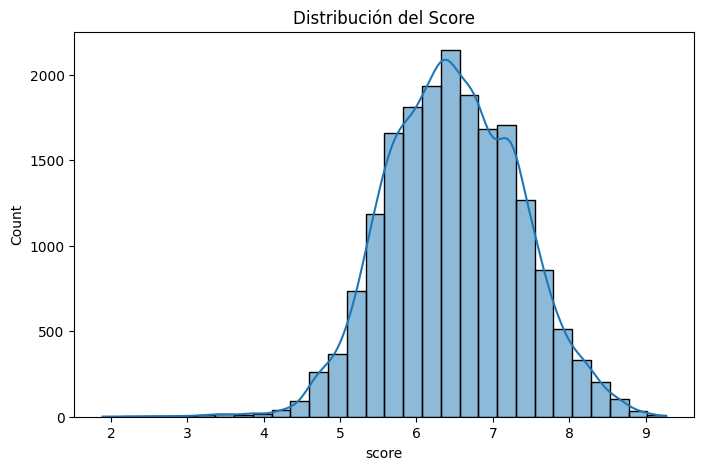

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df["score"], bins=30, kde=True)
plt.title("Distribución del Score")
plt.show()

In [21]:
# La distribución del score presenta una forma aproximadamente normal, con la mayoría de los valores concentrados entre 6 y 7.5. Esto indica que la mayoría de los animes tienen calificaciones medias, siendo poco común encontrar valores extremadamente bajos o muy altos.

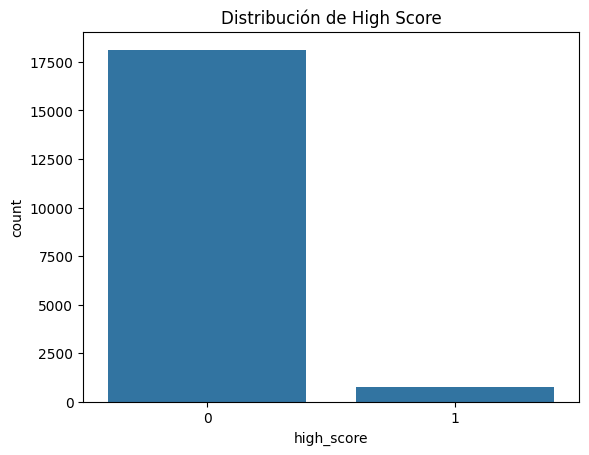

In [22]:
sns.countplot(x="high_score", data=df)
plt.title("Distribución de High Score")
plt.show()

In [23]:
# La variable high_score presenta un fuerte desbalance de clases, donde la mayoría de los animes no alcanzan una calificación alta (score ≥ 8). Esto refleja la distribución real del dataset.

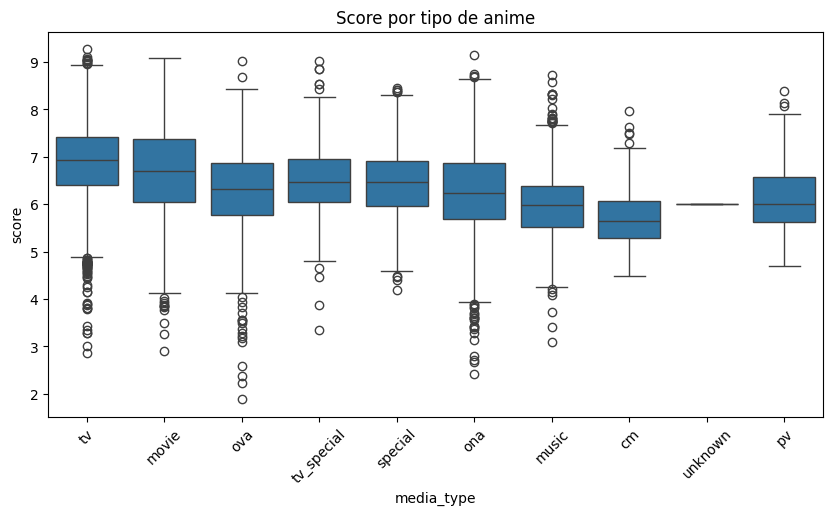

In [24]:
plt.figure(figsize=(10,5))
sns.boxplot(x="media_type", y="score", data=df)
plt.xticks(rotation=45)
plt.title("Score por tipo de anime")
plt.show()

In [25]:
# El análisis por tipo de anime muestra que la mayoría de las categorías tienen distribuciones de score similares, generalmente entre 6 y 7. Sin embargo, algunos tipos como TV y Movie tienden a presentar valores ligeramente más altos. No se observa una diferencia extremadamente marcada entre categorías, aunque sí variaciones en la dispersión.

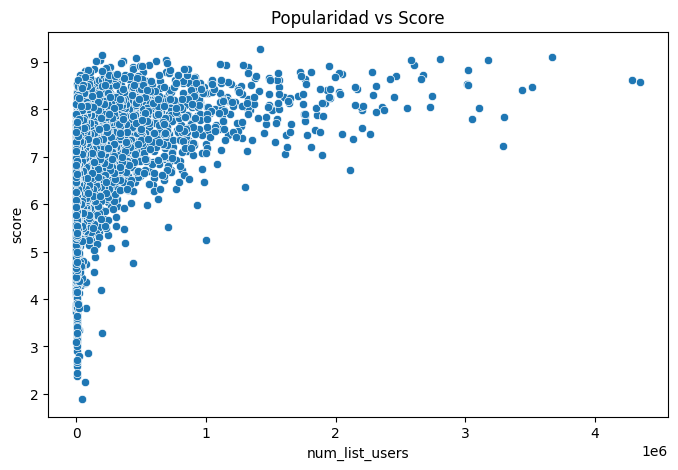

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="num_list_users", y="score", data=df)
plt.title("Popularidad vs Score")
plt.show()

In [27]:
# La relación entre popularidad (num_list_users) y score muestra una ligera tendencia positiva, donde animes más populares tienden a tener mejores calificaciones. Sin embargo, la alta dispersión indica que la popularidad no es un factor determinante fuerte del score.

In [28]:
df["genres"].head()

0    Action, Adult Cast, Award Winning, Sci-Fi, Space
1                   Action, Adult Cast, Sci-Fi, Space
2      Action, Adult Cast, Adventure, Sci-Fi, Shounen
3     Action, Detective, Drama, Mystery, Supernatural
4                 Action, Adventure, Fantasy, Shounen
Name: genres, dtype: str

In [29]:
df["genres_list"] = df["genres"].apply(lambda x: x.split(", "))

In [30]:
from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genres_encoded = mlb.fit_transform(df["genres_list"])

In [31]:
genres_df = pd.DataFrame(genres_encoded, columns=mlb.classes_)

In [32]:
df = pd.concat([df, genres_df], axis=1)

In [33]:
df.head()

,title,media_type,num_episodes,status,rating,score,num_scoring_users,rank,num_list_users,genres,...,Survival,Suspense,Team Sports,Time Travel,Urban Fantasy,Vampire,Video Game,Villainess,Visual Arts,Workplace
0,Cowboy Bebop,tv,26.0,finished_airing,r,8.75,1059425.0,49.0,2051529.0,"Action, Adult Cast, Award Winning, Sci-Fi, Space",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,Cowboy Bebop: Tengoku no Tobira,movie,1.0,finished_airing,r,8.38,231859.0,240.0,411130.0,"Action, Adult Cast, Sci-Fi, Space",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,Trigun,tv,26.0,finished_airing,pg_13,8.22,400891.0,419.0,832704.0,"Action, Adult Cast, Adventure, Sci-Fi, Shounen",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,Witch Hunter Robin,tv,26.0,finished_airing,pg_13,7.25,46530.0,3527.0,129287.0,"Action, Detective, Drama, Mystery, Supernatural",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Bouken Ou Beet,tv,52.0,finished_airing,pg,7.01,7226.0,4893.0,16881.0,"Action, Adventure, Fantasy, Shounen",...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [36]:
# 1. Cargar dataset
df = pd.read_csv("anime-standalone.csv")

# 2. Seleccionar columnas útiles
df = df[
    [
        "title",
        "media_type",
        "num_episodes",
        "status",
        "rating",
        "score",
        "num_scoring_users",
        "rank",
        "num_list_users",
        "genres",
        "studios",
        "start_date"
    ]
].copy()

# 3. Limpiar columnas críticas
df = df.dropna(subset=["score", "genres"]).copy()
df = df.reset_index(drop=True)

# 4. Crear target
df["high_score"] = (df["score"] >= 8).astype(int)

# 5. Transformar géneros
df["genres_list"] = df["genres"].apply(lambda x: x.split(", "))

mlb = MultiLabelBinarizer()
genres_encoded = mlb.fit_transform(df["genres_list"])

genres_df = pd.DataFrame(
    genres_encoded,
    columns=mlb.classes_,
    index=df.index
)

# 6. Crear df_model
df_model = pd.concat([df, genres_df], axis=1)

df_model.head()

KeyError: "['score'] not in index"